# Fish & Marine Organism Rigging & Pipeline Experimentation

This notebook provides step-by-step diagnostic inspection and interactive experimentation for the fish procedural animation and rigging pipeline:

1. **Model Loading & Preprocessing**: Load 3D marine models (Tuna, Shark, Dolphin, Goldfish, Mackerel, Killer Whale).
2. **Segmentation & Fin Classification**: Inspect 3D SDF and vision-language part segmentation with morphological fin classification (`_classify_fin_type`, `_classify_side_fin_type`).
3. **Alignment & Tail Orientation Detection**: Automatic head-tail axis alignment and tail orientation detection (`vertical` vs `horizontal`).
4. **Centerline Spine Extraction & Spline Fitting**: Extract 1D trunk spine nodes and fit a Catmull-Rom spline curve.
5. **Bishop-Frame Lateral Straightening**: Straighten lateral curvature while preserving vertical profile and longitudinal length.
6. **Hierarchical Armature Rigging**: Build connected spine, tail, and fin bone chains.
7. **Automatic Skin Weight Computation**: Compute Laplacian bone heat diffusion weights and inspect per-vertex influences.
8. **Procedural Wave Animation & GLB Export**: Generate direction-aligned swimming waves and export diagnostic artifacts.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Add repository root to path
sys.path.append("..")

from animgen.core.models.model import BaseModelClass
from animgen.core.models.fish import FishModels, PART_COLOR_PALETTE
from animgen.core.armature import Armature, Bone
from animgen.core.spline import Spline
from animgen.animation.animator import Animator
from animgen.animation.wave import chain_wave_generator
from animgen.rigging.skinning import compute_auto_skin_weights, get_skinning_weight_matrix

print("All AnimGen modules loaded successfully!")

All AnimGen modules loaded successfully!


## 1. Select and Load 3D Fish / Marine Model

In [2]:
# Available paint_mesh models in generated_data/models:
AVAILABLE_MODELS = {
    "Tuna": "../generated_data/models/paint_mesh_Tuna.glb",
    "Shark": "../generated_data/models/paint_mesh_Shark.glb",
    "Dolphin": "../generated_data/models/paint_mesh_Dolphin.glb",
    "Goldfish": "../generated_data/models/paint_mesh_Goldfish.glb",
    "Mackeral": "../generated_data/models/paint_mesh_Mackeral.glb",
    "Killer_Whale": "../generated_data/models/paint_mesh_Killer_Whale.glb",
}

# Select organism name
ORGANISM = "Tuna"  # Try: "Shark", "Dolphin", "Goldfish", "Mackeral", "Killer_Whale"
model_path = Path(AVAILABLE_MODELS[ORGANISM])

print(f"Loading model from: {model_path}")
base_model = BaseModelClass(model_path)
mesh = base_model.mesh

print(f"Mesh Summary:")
print(f"  Vertices : {len(mesh.vertices)}")
print(f"  Faces    : {len(mesh.faces)}")
print(f"  Bounds X : [{mesh.bounds[0, 0]:.3f}, {mesh.bounds[1, 0]:.3f}] (span: {mesh.bounds[1, 0] - mesh.bounds[0, 0]:.3f})")
print(f"  Bounds Y : [{mesh.bounds[0, 1]:.3f}, {mesh.bounds[1, 1]:.3f}] (span: {mesh.bounds[1, 1] - mesh.bounds[0, 1]:.3f})")
print(f"  Bounds Z : [{mesh.bounds[0, 2]:.3f}, {mesh.bounds[1, 2]:.3f}] (span: {mesh.bounds[1, 2] - mesh.bounds[0, 2]:.3f})")


Loading model from: ../generated_data/models/paint_mesh_Tuna.glb
Mesh Summary:
  Vertices : 14156
  Faces    : 23068
  Bounds X : [-0.777, 0.965] (span: 1.742)
  Bounds Y : [-0.333, 0.399] (span: 0.732)
  Bounds Z : [-0.201, 0.202] (span: 0.404)


## 2. Initialize Fish Pipeline & Run Segmentation

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:04<00:00,  4.73it/s]



--- Segmentation Results ---
  body                :  19408 faces (84.13%)
  tail                :   2054 faces ( 8.90%)
  dorsal_fin          :    581 faces ( 2.52%)
  left_pectoral_fin   :    502 faces ( 2.18%)
  right_pectoral_fin  :    477 faces ( 2.07%)
  unassigned          :     46 faces ( 0.20%)

--- SAM3 Prompt Backprojection Face Votes ---
  Prompt tail                :   2125 faces with positive votes (max votes: 13)
  Prompt top fin             :   7696 faces with positive votes (max votes: 8)
  Prompt side fin            :   6231 faces with positive votes (max votes: 9)

Exported texture-stripped segmented GLB to: /media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/generated_data/test/seg_tuna_untextured.glb


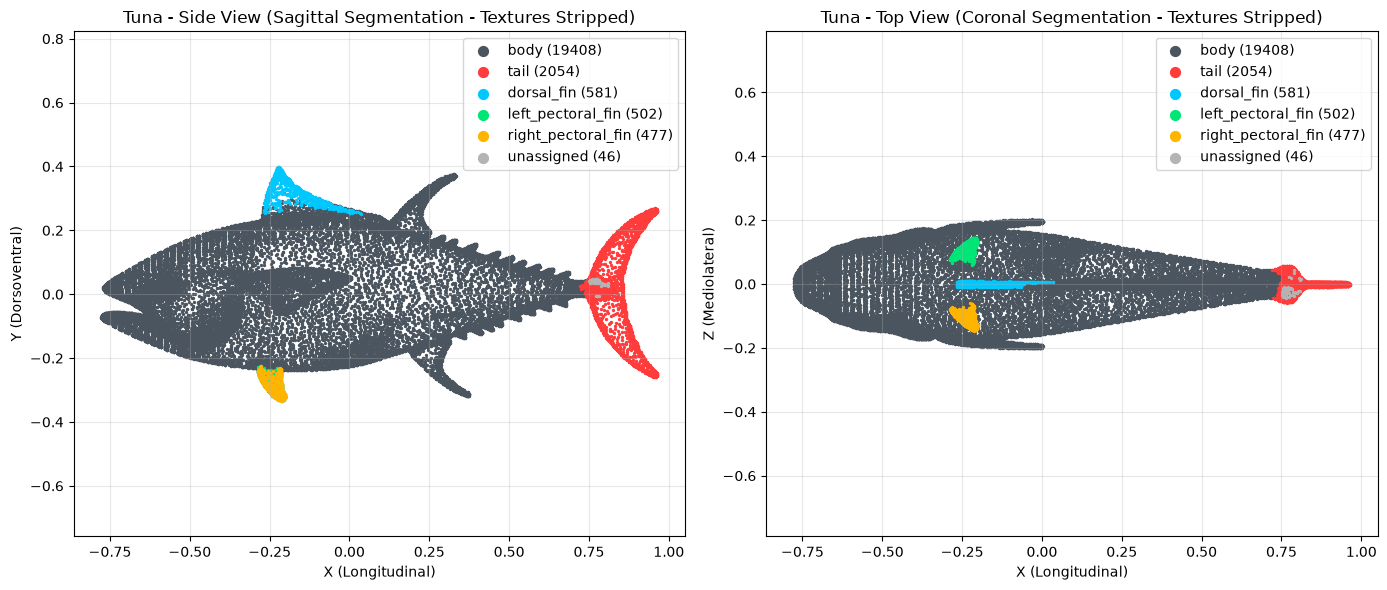

In [3]:
pipeline = FishModels(
    model=base_model,
    num_bones=12,
    num_tail_bones=2,
    rig_tail=True,
    rig_pectoral_fins=True,
    rig_dorsal_fin=True,
    straighten_mesh=True,
    use_sam=True,
)

# 1. Run Segmentation (Subdivided High-Res SDF + SAM3 Vision Inference)
segments = pipeline.segment()

print("\n--- Segmentation Results ---")
total_faces = len(pipeline.model.mesh.faces)
for part_name, faces in segments.items():
    pct = (len(faces) / total_faces) * 100.0
    print(f"  {part_name:20s}: {len(faces):6d} faces ({pct:5.2f}%)")

if pipeline.face_prompt_detected is not None:
    print("\n--- SAM3 Prompt Backprojection Face Votes ---")
    for p, votes in pipeline.face_prompt_detected.items():
        print(f"  Prompt {p:20s}: {np.count_nonzero(votes):6d} faces with positive votes (max votes: {votes.max()})")

# 2. Strip Visual Textures & Create Pure ColorVisuals Segmentation Model
seg_mesh = pipeline.model.mesh.copy()
seg_mesh.visual = trimesh.visual.ColorVisuals(mesh=seg_mesh)

face_colors = np.tile(np.array([120, 120, 120, 255], dtype=np.uint8), (len(seg_mesh.faces), 1))
for part_name, faces in segments.items():
    if part_name in PART_COLOR_PALETTE and len(faces) > 0:
        face_colors[faces] = PART_COLOR_PALETTE[part_name]
seg_mesh.visual.face_colors = face_colors

# Export untextured color-coded segmentation GLB
seg_export_path = Path(f"../generated_data/test/seg_{ORGANISM.lower()}_untextured.glb")
seg_export_path.parent.mkdir(parents=True, exist_ok=True)
seg_mesh.export(seg_export_path)
print(f"\nExported texture-stripped segmented GLB to: {seg_export_path.resolve()}")

# 3. Plot 3D Segmentation Views (Sagittal & Coronal)
v = seg_mesh.vertices
f = seg_mesh.faces
centroids = v[f].mean(axis=1)

fig = plt.figure(figsize=(14, 6))

# Side View (X vs Y)
ax1 = fig.add_subplot(1, 2, 1)
for part_name, faces in segments.items():
    if len(faces) == 0:
        continue
    c_rgba = np.array(PART_COLOR_PALETTE.get(part_name, [180, 180, 180, 255])) / 255.0
    ax1.scatter(centroids[faces, 0], centroids[faces, 1], color=c_rgba, s=2.0, label=f"{part_name} ({len(faces)})")
ax1.set_title(f"{ORGANISM} - Side View (Sagittal Segmentation - Textures Stripped)")
ax1.set_xlabel("X (Longitudinal)")
ax1.set_ylabel("Y (Dorsoventral)")
ax1.legend(loc="upper right", markerscale=5)
ax1.grid(True, alpha=0.3)
ax1.axis("equal")

# Top View (X vs Z)
ax2 = fig.add_subplot(1, 2, 2)
for part_name, faces in segments.items():
    if len(faces) == 0:
        continue
    c_rgba = np.array(PART_COLOR_PALETTE.get(part_name, [180, 180, 180, 255])) / 255.0
    ax2.scatter(centroids[faces, 0], centroids[faces, 2], color=c_rgba, s=2.0, label=f"{part_name} ({len(faces)})")
ax2.set_title(f"{ORGANISM} - Top View (Coronal Segmentation - Textures Stripped)")
ax2.set_xlabel("X (Longitudinal)")
ax2.set_ylabel("Z (Mediolateral)")
ax2.legend(loc="upper right", markerscale=5)
ax2.grid(True, alpha=0.3)
ax2.axis("equal")

plt.tight_layout()
plt.show()


## 3. Fin Classification & Morphology Analytics

Inspect the lean classification methods on the detected fins:
- `_classify_fin_type`: Primary extension direction away from body (`caudal`, `dorsal`, `pectoral`).
- `_classify_side_fin_type`: Side fin stiffness/flexibility morphology (`loosy` vs `straight`).
- `_detect_tail_orientation`: Tail swimming plane (`vertical` vs `horizontal`).

In [4]:
print("--- Fin & Appendage Classification Diagnostics ---\n")

for fin_key in ["tail", "dorsal_fin", "left_pectoral_fin", "right_pectoral_fin"]:
    if fin_key in segments and len(segments[fin_key]) > 0:
        fin_type = pipeline._classify_fin_type(fin_key)
        root_pt, tip_pt = pipeline._get_fin_endpoints(fin_key)
        length = np.linalg.norm(tip_pt - root_pt)
        print(f"[{fin_key}]")
        print(f"  Fin Type         : {fin_type}")
        print(f"  Root Endpoint    : [{root_pt[0]:.3f}, {root_pt[1]:.3f}, {root_pt[2]:.3f}]")
        print(f"  Tip Endpoint     : [{tip_pt[0]:.3f}, {tip_pt[1]:.3f}, {tip_pt[2]:.3f}]")
        print(f"  Estimated Length : {length:.3f}")
        
        if "pectoral" in fin_key:
            side_type = pipeline._classify_side_fin_type(fin_key)
            print(f"  Side Fin Class   : {side_type}")
        print()

--- Fin & Appendage Classification Diagnostics ---

[tail]
  Fin Type         : caudal
  Root Endpoint    : [0.795, -0.102, 0.000]
  Tip Endpoint     : [0.932, 0.247, -0.000]
  Estimated Length : 0.375

[dorsal_fin]
  Fin Type         : dorsal
  Root Endpoint    : [-0.256, 0.306, -0.001]
  Tip Endpoint     : [-0.026, 0.267, 0.004]
  Estimated Length : 0.234

[left_pectoral_fin]
  Fin Type         : pectoral
  Root Endpoint    : [-0.281, -0.242, 0.079]
  Tip Endpoint     : [-0.209, -0.328, 0.138]
  Estimated Length : 0.127
  Side Fin Class   : straight

[right_pectoral_fin]
  Fin Type         : pectoral
  Root Endpoint    : [-0.220, -0.241, -0.068]
  Tip Endpoint     : [-0.213, -0.329, -0.140]
  Estimated Length : 0.113
  Side Fin Class   : straight



## 4. Head/Tail Dynamic Alignment & Tail Orientation Detection

In [5]:
# Run Alignment
pipeline.align()

# Tail Orientation
tail_orient = pipeline._detect_tail_orientation()
print(f"Detected Tail Orientation: {tail_orient}")
print(f"Straightening Axis       : {'z' if tail_orient == 'vertical' else 'y'}")
print(f"Swimming Wave Plane      : {'Lateral XZ Plane' if tail_orient == 'vertical' else 'Dorsoventral XY Plane'}")

# Verify Snout (-X) to Tail (+X) alignment
tail_faces = segments.get("tail", []) or segments.get("Tail Fin", [])
if tail_faces:
    tail_verts = pipeline.model.mesh.vertices[np.unique(pipeline.model.mesh.faces[tail_faces])]
    print(f"Tail Center X Position   : {tail_verts[:, 0].mean():.3f} (Must be positive)")

Detected Tail Orientation: vertical
Straightening Axis       : z
Swimming Wave Plane      : Lateral XZ Plane
Tail Center X Position   : 0.839 (Must be positive)


## 5. Centerline Spine Extraction & Spline Fitting

Runs canonicalization to extract the 1D body spine, fit Catmull-Rom splines, level dorsal-to-tail height, and straighten lateral curvature.


--- Spine & Canonicalization Diagnostic ---
Raw Spine Control Nodes : 16
Dense Source Spine Pts  : 136
Dense Target Spine Pts  : 136


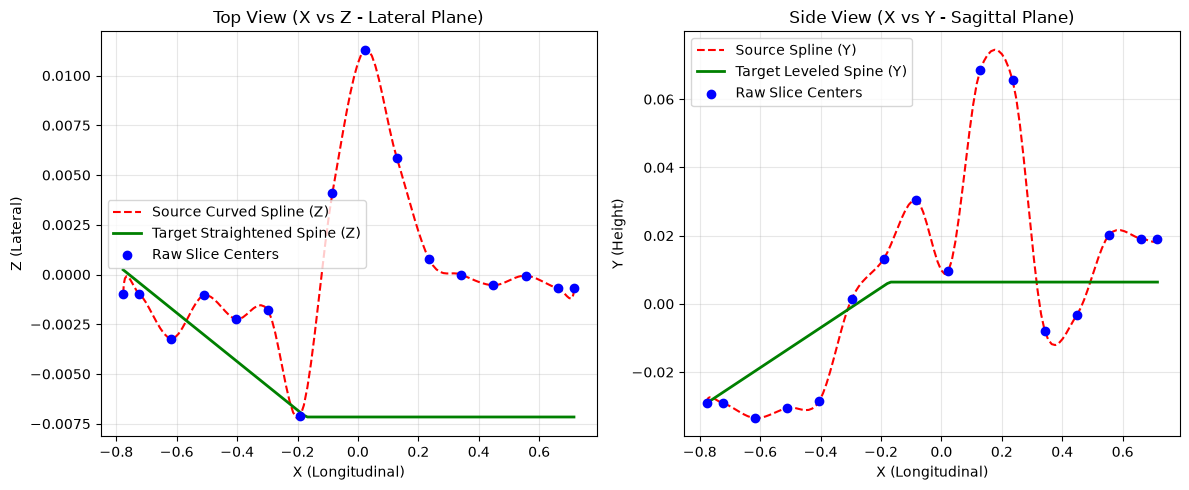

In [6]:
# Run Canonicalization
straight_mesh = pipeline.canonicalize(segments)
pipeline.model.mesh = straight_mesh

print("\n--- Spine & Canonicalization Diagnostic ---")
print(f"Raw Spine Control Nodes : {len(pipeline.raw_spine_points)}")
print(f"Dense Source Spine Pts  : {len(pipeline.source_spine)}")
print(f"Dense Target Spine Pts  : {len(pipeline.target_spine)}")

# Plot Spine Points vs Target Spine
fig = plt.figure(figsize=(12, 5))

# Top View (X vs Z)
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(pipeline.source_spine[:, 0], pipeline.source_spine[:, 2], 'r--', label='Source Curved Spline (Z)')
ax1.plot(pipeline.target_spine[:, 0], pipeline.target_spine[:, 2], 'g-', lw=2, label='Target Straightened Spine (Z)')
ax1.scatter(pipeline.raw_spine_points[:, 0], pipeline.raw_spine_points[:, 2], color='blue', zorder=5, label='Raw Slice Centers')
ax1.set_title("Top View (X vs Z - Lateral Plane)")
ax1.set_xlabel("X (Longitudinal)")
ax1.set_ylabel("Z (Lateral)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Side View (X vs Y)
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(pipeline.source_spine[:, 0], pipeline.source_spine[:, 1], 'r--', label='Source Spline (Y)')
ax2.plot(pipeline.target_spine[:, 0], pipeline.target_spine[:, 1], 'g-', lw=2, label='Target Leveled Spine (Y)')
ax2.scatter(pipeline.raw_spine_points[:, 0], pipeline.raw_spine_points[:, 1], color='blue', zorder=5, label='Raw Slice Centers')
ax2.set_title("Side View (X vs Y - Sagittal Plane)")
ax2.set_xlabel("X (Longitudinal)")
ax2.set_ylabel("Y (Height)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Hierarchical Armature Rigging

Constructs the hierarchical `Armature` with connected spine bones, tail fin chain, side pectoral fin bones, and optional dorsal fin bone.

In [7]:
armature = pipeline.rig(segments)
pipeline.model.armature = armature

print(f"\n--- Armature Construction Summary ---")
print(f"Total Bones Constructed: {len(armature.bones_list)}\n")
print(f"{'Bone ID':<25s} | {'Parent ID':<25s} | {'Head (X, Y, Z)':<24s} -> {'Tail (X, Y, Z)':<24s}")
print("-" * 105)

for b in armature.bones_list:
    parent_id = b.parent.id if b.parent else "None (ROOT)"
    head_str = f"({b.head[0]:.2f}, {b.head[1]:.2f}, {b.head[2]:.2f})"
    tail_str = f"({b.tail[0]:.2f}, {b.tail[1]:.2f}, {b.tail[2]:.2f})"
    print(f"{b.id:<25s} | {parent_id:<25s} | {head_str:<24s} -> {tail_str:<24s}")

# Validate Armature tree consistency
armature.validify_tree()
print("\nArmature tree validation PASSED: No cycles, all parent-child links consistent.")


--- Armature Construction Summary ---
Total Bones Constructed: 15

Bone ID                   | Parent ID                 | Head (X, Y, Z)           -> Tail (X, Y, Z)          
---------------------------------------------------------------------------------------------------------
spine_0                   | None (ROOT)               | (-0.78, -0.03, 0.00)     -> (-0.68, -0.02, -0.00)   
spine_1                   | spine_0                   | (-0.68, -0.02, -0.00)    -> (-0.51, -0.01, -0.00)   
spine_2                   | spine_1                   | (-0.51, -0.01, -0.00)    -> (-0.36, -0.00, -0.00)   
spine_3                   | spine_2                   | (-0.36, -0.00, -0.00)    -> (-0.19, 0.01, -0.01)    
spine_4                   | spine_3                   | (-0.19, 0.01, -0.01)     -> (-0.04, 0.01, -0.01)    
spine_5                   | spine_4                   | (-0.04, 0.01, -0.01)     -> (0.13, 0.01, -0.01)     
spine_6                   | spine_5                   | (0.13, 

## 7. 3D Visualization: Straightened Mesh & Armature Bones

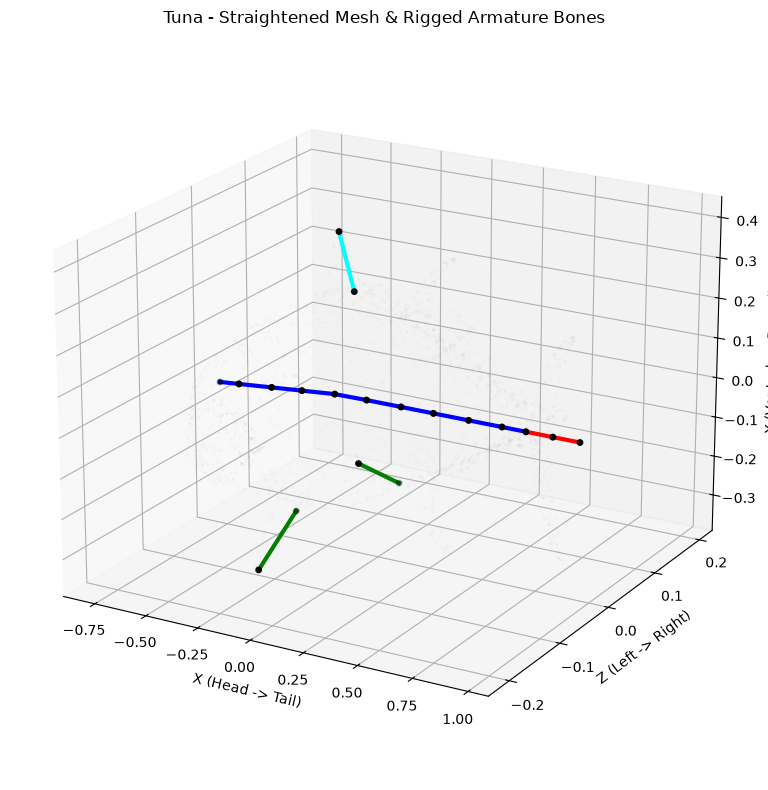

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# Subsample vertices for crisp 3D rendering
v_sub = straight_mesh.vertices[::max(1, len(straight_mesh.vertices) // 2000)]
ax.scatter(v_sub[:, 0], v_sub[:, 2], v_sub[:, 1], c='gray', alpha=0.15, s=2, label='Mesh Vertices')

# Plot Bone Chains
for b in armature.bones_list:
    h, t = np.array(b.head), np.array(b.tail)
    if "spine" in b.id:
        color = 'blue'
    elif "tail" in b.id:
        color = 'red'
    elif "pectoral" in b.id:
        color = 'green'
    elif "dorsal" in b.id:
        color = 'cyan'
    else:
        color = 'magenta'
    
    # Plot (X, Z, Y) for standard graphics viewing orientation
    ax.plot([h[0], t[0]], [h[2], t[2]], [h[1], t[1]], color=color, lw=3)
    ax.scatter([h[0], t[0]], [h[2], t[2]], [h[1], t[1]], color='black', s=15)

ax.set_title(f"{ORGANISM} - Straightened Mesh & Rigged Armature Bones")
ax.set_xlabel("X (Head -> Tail)")
ax.set_ylabel("Z (Left -> Right)")
ax.set_zlabel("Y (Ventral -> Dorsal)")
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

## 8. Automatic Skin Weight Diffusion & Influences

In [9]:
# Compute skin weights
skin_weights = pipeline.model.compute_skin_weights()
weight_matrix, bone_ids = get_skinning_weight_matrix(straight_mesh, armature)

print("--- Skinning Weight Diagnostics ---")
print(f"Weight Matrix Shape : {weight_matrix.shape} (Vertices x Bones)")
print(f"Min Weight          : {weight_matrix.min():.4f}")
print(f"Max Weight          : {weight_matrix.max():.4f}")

row_sums = weight_matrix.sum(axis=1)
print(f"Row Sums Check      : min={row_sums.min():.4f}, max={row_sums.max():.4f} (must be 1.0)")
assert np.allclose(row_sums, 1.0, atol=1e-4), "Skin weights do not sum to 1.0!"

print("\nPer-Bone Vertex Influences (vertices where weight > 0.1):")
for j, bid in enumerate(bone_ids):
    num_influenced = int(np.sum(weight_matrix[:, j] > 0.1))
    max_w = float(weight_matrix[:, j].max())
    print(f"  {bid:<25s}: {num_influenced:5d} vertices (max weight: {max_w:.3f})")

--- Skinning Weight Diagnostics ---
Weight Matrix Shape : (14156, 15) (Vertices x Bones)
Min Weight          : 0.0000
Max Weight          : 1.0000
Row Sums Check      : min=1.0000, max=1.0000 (must be 1.0)

Per-Bone Vertex Influences (vertices where weight > 0.1):
  spine_0                  :  2373 vertices (max weight: 0.877)
  spine_1                  :  3560 vertices (max weight: 0.795)
  spine_2                  :  2543 vertices (max weight: 0.335)
  spine_3                  :  2379 vertices (max weight: 0.285)
  spine_4                  :  2027 vertices (max weight: 0.403)
  spine_5                  :  2995 vertices (max weight: 0.376)
  spine_6                  :  3313 vertices (max weight: 0.460)
  spine_7                  :  3273 vertices (max weight: 0.581)
  spine_8                  :  2190 vertices (max weight: 0.718)
  spine_9                  :  1250 vertices (max weight: 0.872)
  tail_0                   :  1640 vertices (max weight: 0.995)
  tail_1                   :   

## 9. Procedural Wave Animation & Intermediate Artifact Export

In [10]:
# Run Animation
animator = pipeline.animate()
pipeline.model.animator = animator

print("--- Registered Animation Clips ---")
for clip_name in animator.animations:
    clip = animator.get_animation_clip(clip_name)
    print(f"  Clip: '{clip_name}' (Duration: {clip.duration:.2f}s, Loopable: {clip.is_loopable})")

# Export all diagnostic intermediate steps
output_dir = Path(f"../generated_data/test/fish_rig_exp_{ORGANISM.lower()}")
saved_artifacts = pipeline.save_intermediate_artifacts(output_dir)

print(f"\nSaved Intermediate Diagnostic Artifacts to {output_dir.resolve()}:")
for step_name, file_path in saved_artifacts.items():
    size_kb = file_path.stat().st_size / 1024.0
    print(f"  [{step_name:25s}] -> {file_path.name} ({size_kb:7.1f} KB)")

--- Registered Animation Clips ---
  Clip: 'slow' (Duration: 2.50s, Loopable: True)
  Clip: 'fast' (Duration: 1.00s, Loopable: True)
  Clip: 'idle' (Duration: 3.50s, Loopable: True)

Saved Intermediate Diagnostic Artifacts to /media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/generated_data/test/fish_rig_exp_tuna:
  [01_segmented_mesh        ] -> 01_segmented_mesh.glb (  492.6 KB)
  [02_extracted_1d_spine    ] -> 02_extracted_1d_spine.glb (   23.7 KB)
  [03_evaluated_spline      ] -> 03_evaluated_spline.glb (   66.6 KB)
  [04_canonical_mesh        ] -> 04_canonical_mesh.glb ( 3287.0 KB)
  [05_rigged_armature       ] -> 05_rigged_armature.glb ( 3622.0 KB)
  [06_animated_fish         ] -> 06_animated_fish.glb ( 3683.8 KB)


## 10. Batch Showcase: Run Pipeline Across All Marine Organisms

Executes the complete pipeline (Segmentation, Morphology Classification, Dynamic Alignment, Straightening, and Armature Rigging) across all 6 marine models, displaying texture-stripped segmentation plots and a consolidated comparative summary table.


Processing & Exporting Full Pipeline: Tuna (paint_mesh_Tuna.glb)


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:04<00:00,  4.91it/s]



Saved Pipeline Artifacts to: /media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/generated_data/test/fish_rig_exp_tuna
  [01_segmented_mesh        ] -> 01_segmented_mesh.glb (  492.6 KB)
  [02_extracted_1d_spine    ] -> 02_extracted_1d_spine.glb (   23.7 KB)
  [03_evaluated_spline      ] -> 03_evaluated_spline.glb (   66.6 KB)
  [04_canonical_mesh        ] -> 04_canonical_mesh.glb ( 3287.0 KB)
  [05_rigged_armature       ] -> 05_rigged_armature.glb ( 3621.8 KB)
  [06_animated_fish         ] -> 06_animated_fish.glb ( 3679.6 KB)


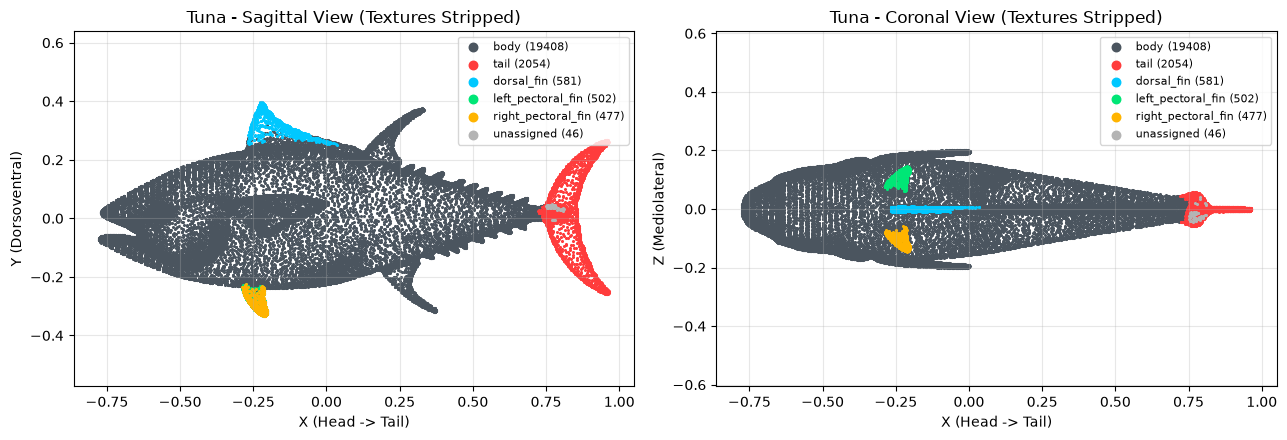


Processing & Exporting Full Pipeline: Shark (paint_mesh_Shark.glb)


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:03<00:00,  5.13it/s]



Saved Pipeline Artifacts to: /media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/generated_data/test/fish_rig_exp_shark
  [01_segmented_mesh        ] -> 01_segmented_mesh.glb (  352.3 KB)
  [02_extracted_1d_spine    ] -> 02_extracted_1d_spine.glb (   23.7 KB)
  [03_evaluated_spline      ] -> 03_evaluated_spline.glb (   66.6 KB)
  [04_canonical_mesh        ] -> 04_canonical_mesh.glb ( 2325.0 KB)
  [05_rigged_armature       ] -> 05_rigged_armature.glb ( 2560.1 KB)
  [06_animated_fish         ] -> 06_animated_fish.glb ( 2617.9 KB)


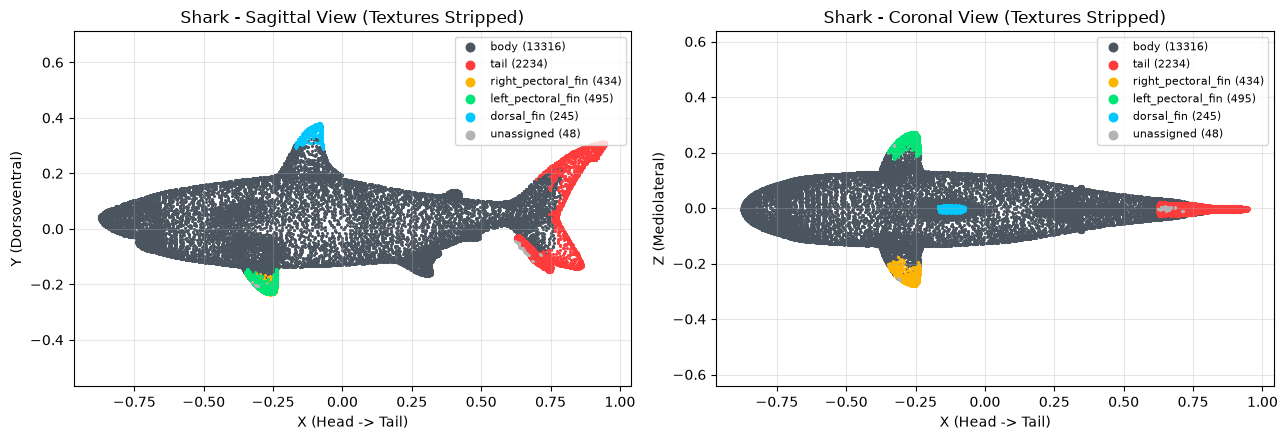


Processing & Exporting Full Pipeline: Dolphin (paint_mesh_Dolphin.glb)


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:03<00:00,  5.30it/s]



Saved Pipeline Artifacts to: /media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/generated_data/test/fish_rig_exp_dolphin
  [01_segmented_mesh        ] -> 01_segmented_mesh.glb (  382.6 KB)
  [02_extracted_1d_spine    ] -> 02_extracted_1d_spine.glb (   23.7 KB)
  [03_evaluated_spline      ] -> 03_evaluated_spline.glb (   66.6 KB)
  [04_canonical_mesh        ] -> 04_canonical_mesh.glb ( 2116.2 KB)
  [05_rigged_armature       ] -> 05_rigged_armature.glb ( 2368.0 KB)
  [06_animated_fish         ] -> 06_animated_fish.glb ( 2425.8 KB)


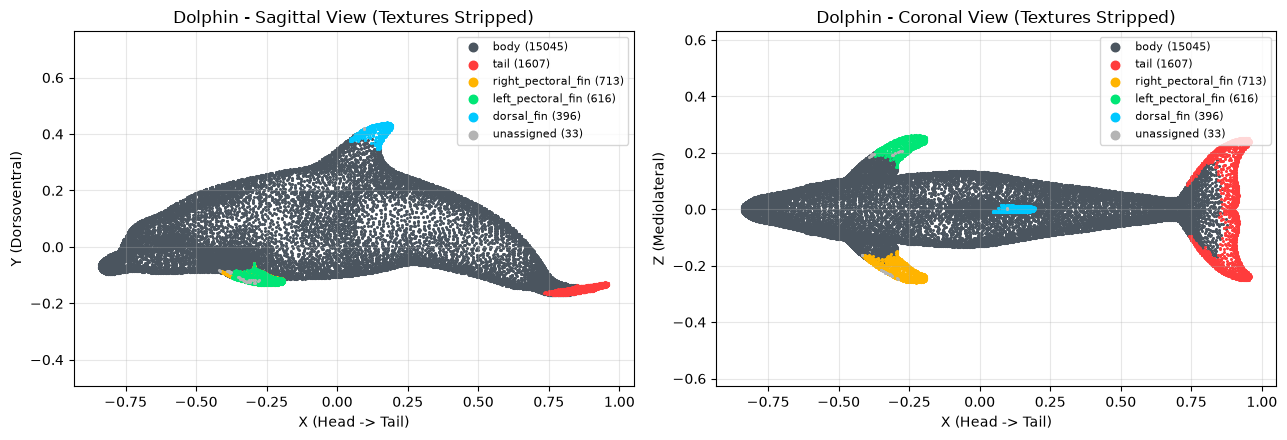


Processing & Exporting Full Pipeline: Goldfish (paint_mesh_Goldfish.glb)


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:04<00:00,  4.69it/s]



Saved Pipeline Artifacts to: /media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/generated_data/test/fish_rig_exp_goldfish
  [01_segmented_mesh        ] -> 01_segmented_mesh.glb ( 1066.7 KB)
  [02_extracted_1d_spine    ] -> 02_extracted_1d_spine.glb (   23.7 KB)
  [03_evaluated_spline      ] -> 03_evaluated_spline.glb (   66.6 KB)
  [04_canonical_mesh        ] -> 04_canonical_mesh.glb ( 4706.0 KB)
  [05_rigged_armature       ] -> 05_rigged_armature.glb ( 5428.7 KB)
  [06_animated_fish         ] -> 06_animated_fish.glb ( 5486.5 KB)


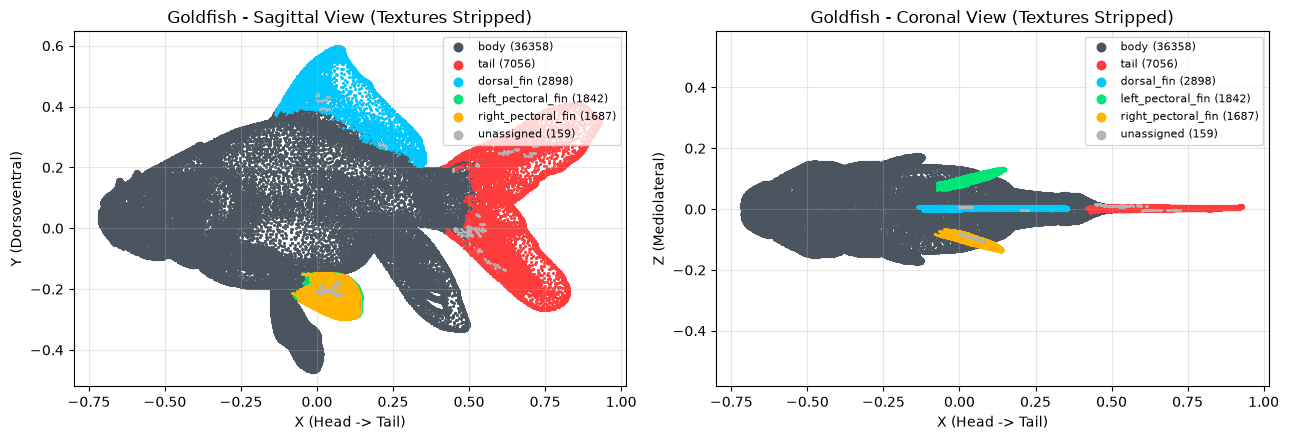


Processing & Exporting Full Pipeline: Mackeral (paint_mesh_Mackeral.glb)


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:03<00:00,  5.36it/s]



Saved Pipeline Artifacts to: /media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/generated_data/test/fish_rig_exp_mackeral
  [01_segmented_mesh        ] -> 01_segmented_mesh.glb (  343.4 KB)
  [02_extracted_1d_spine    ] -> 02_extracted_1d_spine.glb (   23.7 KB)
  [03_evaluated_spline      ] -> 03_evaluated_spline.glb (   66.6 KB)
  [04_canonical_mesh        ] -> 04_canonical_mesh.glb ( 3003.0 KB)
  [05_rigged_armature       ] -> 05_rigged_armature.glb ( 3236.5 KB)
  [06_animated_fish         ] -> 06_animated_fish.glb ( 3294.3 KB)


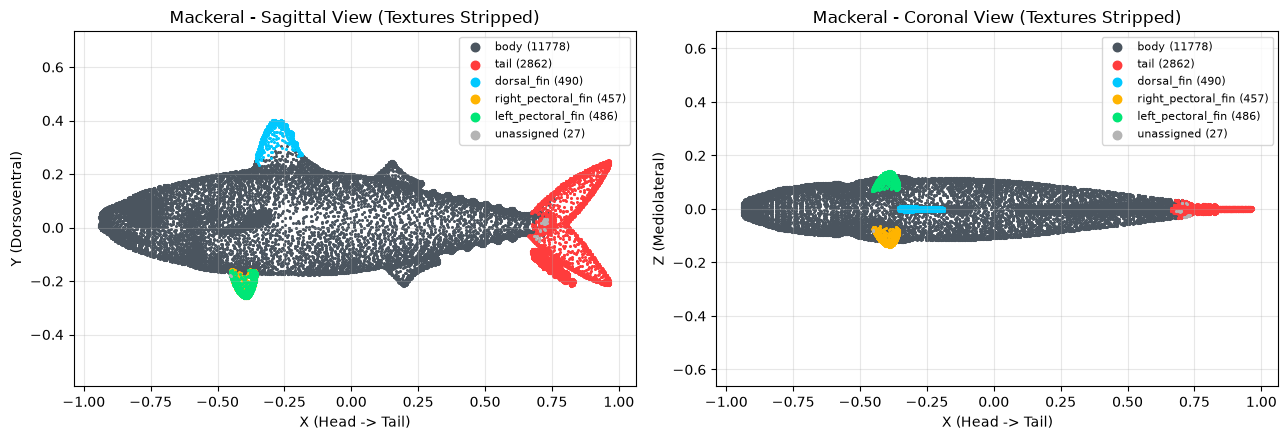


Processing & Exporting Full Pipeline: Killer_Whale (paint_mesh_Killer_Whale.glb)


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:03<00:00,  5.50it/s]



Saved Pipeline Artifacts to: /media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/generated_data/test/fish_rig_exp_killer_whale
  [01_segmented_mesh        ] -> 01_segmented_mesh.glb (  502.0 KB)
  [02_extracted_1d_spine    ] -> 02_extracted_1d_spine.glb (   23.7 KB)
  [03_evaluated_spline      ] -> 03_evaluated_spline.glb (   66.6 KB)
  [04_canonical_mesh        ] -> 04_canonical_mesh.glb ( 2479.8 KB)
  [05_rigged_armature       ] -> 05_rigged_armature.glb ( 2827.1 KB)
  [06_animated_fish         ] -> 06_animated_fish.glb ( 2884.9 KB)


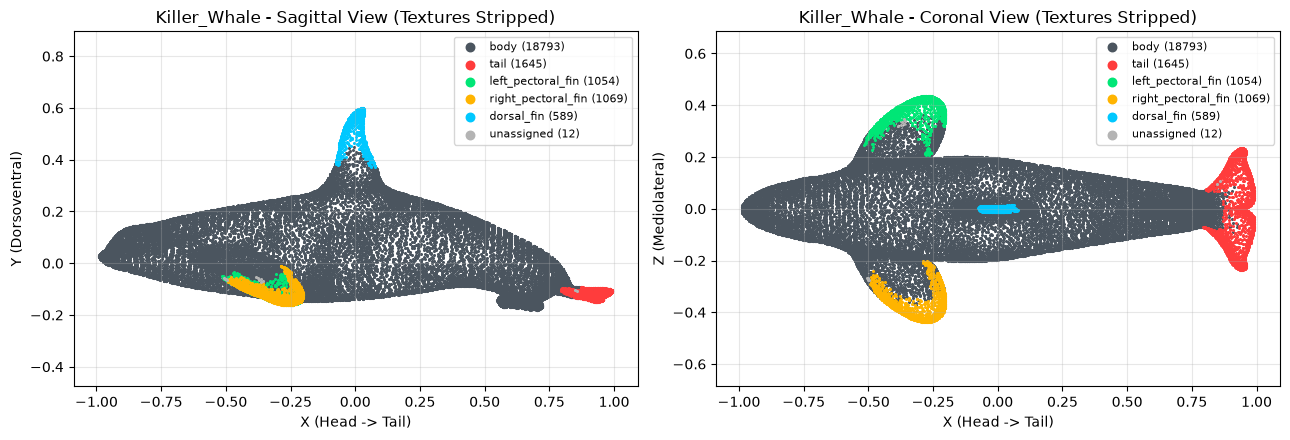


                                        CONSOLIDATED BATCH PIPELINE BENCHMARK SUMMARY                                        
Organism       | Faces   | Tail Fin  | Left Fin  | Right Fin  | Top Fin  | Tail Orient  | Side Fin Class  | Bones  | Artifacts
-----------------------------------------------------------------------------------------------------------------------------
Tuna           | 23068   | 2054      | 502       | 477        | 581      | vertical     | straight        | 14     | 6     saved
Shark          | 16772   | 2234      | 495       | 434        | 245      | vertical     | straight        | 14     | 6     saved
Dolphin        | 18410   | 1607      | 616       | 713        | 396      | horizontal   | straight        | 14     | 6     saved
Goldfish       | 50000   | 7056      | 1842      | 1687       | 2898     | vertical     | loosy           | 14     | 6     saved
Mackeral       | 16100   | 2862      | 486       | 457        | 490      | vertical     | straight      

In [11]:
# Batch Showcase: Process and save all pipeline intermediate artifacts across all models
batch_summary = []

for org_name, m_path_str in AVAILABLE_MODELS.items():
    m_path = Path(m_path_str)
    if not m_path.exists():
        print(f"Skipping {org_name}: file not found at {m_path}")
        continue
    
    print(f"\n{'='*75}")
    print(f"Processing & Exporting Full Pipeline: {org_name} ({m_path.name})")
    print(f"{'='*75}")
    
    # 1. Initialize pipeline with use_sam=True
    model_obj = BaseModelClass(m_path)
    pipe = FishModels(model=model_obj, straighten_mesh=True, use_sam=True)
    
    # 2. Step-by-Step Pipeline Execution
    segs = pipe.segment()
    total_f = len(pipe.model.mesh.faces)
    
    tail_orient = pipe._detect_tail_orientation()
    pipe.align()
    straight_m = pipe.canonicalize(segs)
    pipe.model.mesh = straight_m
    arm = pipe.rig(segs)
    pipe.model.armature = arm
    
    # Compute Skin Weights & Animate
    skin_weights = pipe.model.compute_skin_weights()
    animator = pipe.animate()
    pipe.model.animator = animator
    
    # 3. Save all intermediate artifacts (01_segmented_mesh to 06_animated_fish)
    org_out_dir = Path(f"../generated_data/test/fish_rig_exp_{org_name.lower()}")
    saved_arts = pipe.save_intermediate_artifacts(org_out_dir)
    
    print(f"\nSaved Pipeline Artifacts to: {org_out_dir.resolve()}")
    for step_name, f_path in saved_arts.items():
        size_kb = f_path.stat().st_size / 1024.0
        print(f"  [{step_name:25s}] -> {f_path.name} ({size_kb:7.1f} KB)")
    
    # 4. Record Metrics for Comparative Table
    tail_f = len(segs.get('tail', []) or segs.get('Tail Fin', []))
    left_f = len(segs.get('left_pectoral_fin', []) or segs.get('Left Pectoral Fin', []))
    right_f = len(segs.get('right_pectoral_fin', []) or segs.get('Right Pectoral Fin', []))
    top_f = len(segs.get('dorsal_fin', []) or segs.get('Top Fin', []))
    unassigned_f = len(segs.get('unassigned', []))
    
    side_class = pipe._classify_side_fin_type('left_pectoral_fin') if left_f > 0 else 'none'
    
    batch_summary.append({
        'Organism': org_name,
        'Total Faces': total_f,
        'Tail Fin': tail_f,
        'Left Fin': left_f,
        'Right Fin': right_f,
        'Top Fin': top_f,
        'Unassigned': unassigned_f,
        'Tail Orient': tail_orient,
        'Side Fin Type': side_class,
        'Bones': len(arm.bones_list),
        'Artifacts': len(saved_arts)
    })
    
    # 5. Visualize Texture-Stripped Segmentation (Side & Top views)
    seg_m = pipe.initial_mesh.copy()
    seg_m.visual = trimesh.visual.ColorVisuals(mesh=seg_m)
    v = seg_m.vertices
    f = seg_m.faces
    centroids = v[f].mean(axis=1)
    
    fig, (ax_side, ax_top) = plt.subplots(1, 2, figsize=(13, 4.5))
    
    # Side View (X vs Y)
    for part_name, f_list in segs.items():
        if len(f_list) == 0:
            continue
        c_rgba = np.array(PART_COLOR_PALETTE.get(part_name, [180, 180, 180, 255])) / 255.0
        ax_side.scatter(centroids[f_list, 0], centroids[f_list, 1], color=c_rgba, s=1.5, label=f"{part_name} ({len(f_list)})")
    ax_side.set_title(f"{org_name} - Sagittal View (Textures Stripped)")
    ax_side.set_xlabel("X (Head -> Tail)")
    ax_side.set_ylabel("Y (Dorsoventral)")
    ax_side.legend(loc='upper right', markerscale=5, fontsize=8)
    ax_side.grid(True, alpha=0.3)
    ax_side.axis('equal')
    
    # Top View (X vs Z)
    for part_name, f_list in segs.items():
        if len(f_list) == 0:
            continue
        c_rgba = np.array(PART_COLOR_PALETTE.get(part_name, [180, 180, 180, 255])) / 255.0
        ax_top.scatter(centroids[f_list, 0], centroids[f_list, 2], color=c_rgba, s=1.5, label=f"{part_name} ({len(f_list)})")
    ax_top.set_title(f"{org_name} - Coronal View (Textures Stripped)")
    ax_top.set_xlabel("X (Head -> Tail)")
    ax_top.set_ylabel("Z (Mediolateral)")
    ax_top.legend(loc='upper right', markerscale=5, fontsize=8)
    ax_top.grid(True, alpha=0.3)
    ax_top.axis('equal')
    
    plt.tight_layout()
    plt.show()

# Print Consolidated Comparative Table
print(f"\n{'='*125}")
print(f"{'CONSOLIDATED BATCH PIPELINE BENCHMARK SUMMARY':^125}")
print(f"{'='*125}")
print(f"{'Organism':<14s} | {'Faces':<7s} | {'Tail Fin':<9s} | {'Left Fin':<9s} | {'Right Fin':<10s} | {'Top Fin':<8s} | {'Tail Orient':<12s} | {'Side Fin Class':<15s} | {'Bones':<6s} | {'Artifacts'}")
print(f"{'-'*125}")
for s in batch_summary:
    print(f"{s['Organism']:<14s} | {s['Total Faces']:<7d} | {s['Tail Fin']:<9d} | {s['Left Fin']:<9d} | {s['Right Fin']:<10d} | {s['Top Fin']:<8d} | {s['Tail Orient']:<12s} | {s['Side Fin Type']:<15s} | {s['Bones']:<6d} | {s['Artifacts']:<5d} saved")
print(f"{'='*125}\n")
